# 文件: chart_28_1.py

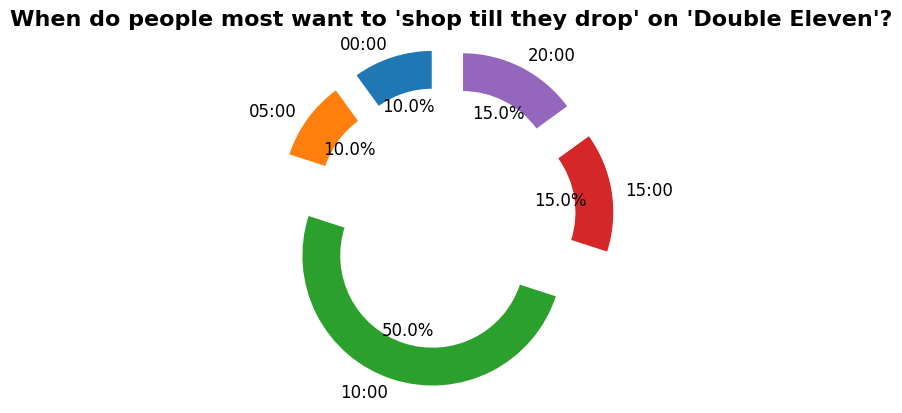

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Time period labels
labels = ["00:00", "05:00", "10:00", "15:00", "20:00"]
# Simulated proportion data (can be replaced according to actual needs, values here are for demonstration), values are just examples
sizes = [10, 10, 50, 15, 15]  
# Gap in the donut chart (to make the donut more obvious), here set uniformly to 0.3, can be adjusted
explode = [0.3] * len(labels)  

fig, ax = plt.subplots()

# Draw a donut chart, wedgeprops controls the width and other styles of the donut
ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    autopct="%1.1f%%",  # Display percentage
    startangle=90,      # Starting angle
    wedgeprops={"width": 0.3, "edgecolor": "white"},  # Donut width, edge color
    textprops={"fontsize": 12}  # Text font size
)
ax.set_title("When do people most want to 'shop till they drop' on 'Double Eleven'?", fontsize=16, fontweight="bold")

# Keep the pie chart circular (to avoid stretching and distortion)
ax.axis("equal")  

plt.show()

# 文件: chart_28_2.py

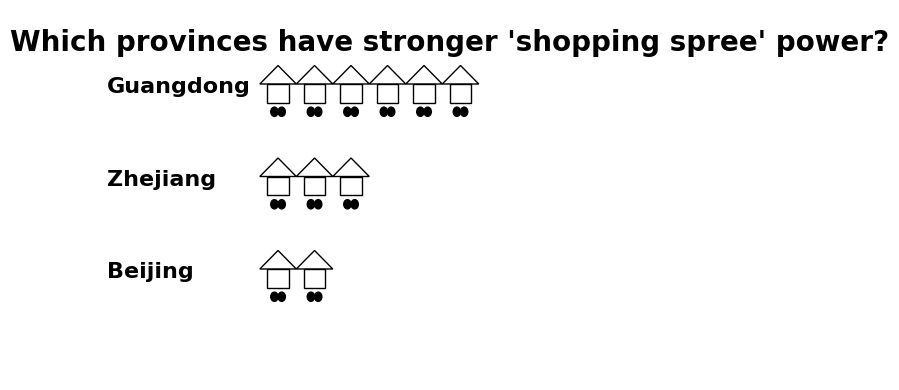

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Data: Provinces and corresponding shopping cart quantities
data = {
    "Guangdong": 6,
    "Zhejiang": 3,
    "Beijing": 2
}
# Province coordinates (y-axis position, controlling vertical layout)
province_y = {
    "Guangdong": 2,
    "Zhejiang": 1,
    "Beijing": 0
}
# Basic size of the shopping cart
cart_width = 0.3
cart_height = 0.2

# Create a canvas
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 7)
ax.set_ylim(-1, 3)
ax.axis('off')  # Hide the axes

# Draw the title - Modified the x-coordinate and alignment
ax.text(
    3.5, 2.8, "Which provinces have stronger 'shopping spree' power?", 
    fontsize=20, fontweight='bold',
    ha='center', va='top'
)

# Define a function to draw a single shopping cart
def draw_cart(x, y):
    """
    Draw a simplified shopping cart icon at position (x, y)
    """
    # Shopping cart basket (rectangle)
    cart_basket = patches.Rectangle(
        (x, y), cart_width, cart_height,
        facecolor='none', edgecolor='black'
    )
    ax.add_patch(cart_basket)
    # Shopping cart handle (simulated by a polygon)
    cart_handle = patches.Polygon(
        [[x - 0.1, y + cart_height],
         [x + cart_width + 0.1, y + cart_height],
         [x + cart_width / 2, y + cart_height + 0.2]],
        facecolor='none', edgecolor='black'
    )
    ax.add_patch(cart_handle)
    # Shopping cart wheels (two small circles)
    wheel1 = patches.Circle((x + 0.1, y - 0.1), 0.05, color='black')
    wheel2 = patches.Circle((x + 0.2, y - 0.1), 0.05, color='black')
    ax.add_patch(wheel1)
    ax.add_patch(wheel2)

# Iterate through the data to draw province names + shopping carts
for province, count in data.items():
    # Draw the province text
    ax.text(
        -1.2, province_y[province] + 0.1, 
        province, fontsize=16, fontweight='bold'
    )
    # Loop to draw shopping carts
    for i in range(count):
        cart_x = 1 + i * (cart_width + 0.2)  # Horizontal spacing between shopping carts
        draw_cart(cart_x, province_y[province])

plt.tight_layout()
plt.show()

# 文件: chart_28_3.py

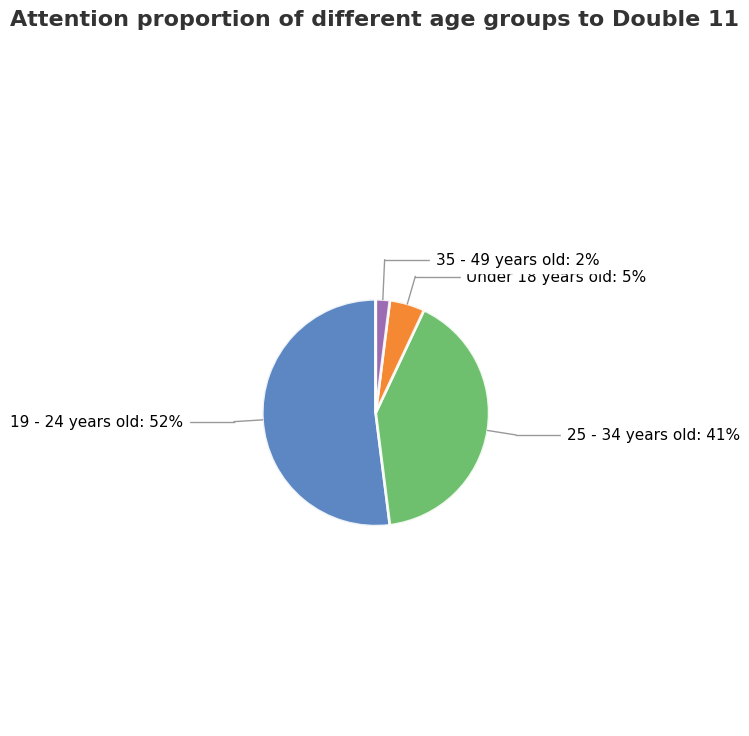

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data definition
age_groups = ["19 - 24 years old", "25 - 34 years old", "Under 18 years old", "35 - 49 years old", "Over 50 years old"]
age_percentages = [52, 41, 5, 2, 0]
age_colors = ['#4A7ABC', '#5EB95E', '#F37B1D', '#905CA9', '#E5E5E5']

# Create a canvas
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

# Draw a beautified pie chart
wedges, texts = ax.pie(
    age_percentages,
    labels=None,
    autopct=None,
    startangle=90,
    colors=age_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    pctdistance=0.8,
)

# Add a shadow effect to the pie chart
for w in wedges:
    w.set_alpha(0.9)
    w.set_zorder(1)

# Set the title
ax.set_title("Attention proportion of different age groups to Double 11", fontsize=16, pad=25,
              fontweight='bold', color='#333333')
ax.axis('equal')  # Ensure the pie chart is circular

# Optimize the label position calculation, using a diagonal + horizontal line style
label_positions = []

for i, (wedge, group, percent) in enumerate(zip(wedges, age_groups, age_percentages)):
    if percent == 0:  # Skip the 0% part
        continue

    # Get the angle of the wedge
    ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
    rad = np.deg2rad(ang)
    y = np.sin(rad)
    x = np.cos(rad)

    # Intelligently adjust the label distance
    angle = wedge.theta2 - wedge.theta1
    base_radius = 1.25
    radius = base_radius + max(0, 0.3 - angle / 180)

    # Calculate the end points of the diagonal line and the horizontal line
    line1_length = 0.25
    line2_length = 0.4

    line1_end_x = x * (1 + line1_length)
    line1_end_y = y * (1 + line1_length)

    if x > 0:  # Right - side labels
        line2_end_x = line1_end_x + line2_length
        line2_end_y = line1_end_y
    else:  # Left - side labels
        line2_end_x = line1_end_x - line2_length
        line2_end_y = line1_end_y

    # Check if there is an overlap with existing labels
    overlap = False
    label_pos = (line2_end_x, line2_end_y)

    for pos in label_positions:
        dist = np.sqrt((label_pos[0] - pos[0]) ** 2 + (label_pos[1] - pos[1]) ** 2)
        if dist < 0.3:
            overlap = True
            if x > 0:  # Move the right - side label up
                line1_end_y += 0.1
                line2_end_y += 0.1
            else:  # Move the left - side label down
                line1_end_y -= 0.1
                line2_end_y -= 0.1
            break

    label_positions.append(label_pos)

    # Draw the two - segment connection line
    ax.plot([x, line1_end_x], [y, line1_end_y], color='#999999', linestyle='-', linewidth=1)
    ax.plot([line1_end_x, line2_end_x], [line1_end_y, line2_end_y], color='#999999', linestyle='-', linewidth=1)

    # Add label text
    if x > 0:
        ax.text(line2_end_x + 0.05, line2_end_y, f"{group}: {percent}%",
                ha='left', va='center', fontsize=11, backgroundcolor='white')
    else:
        ax.text(line2_end_x - 0.05, line2_end_y, f"{group}: {percent}%",
                ha='right', va='center', fontsize=11, backgroundcolor='white')

# Adjust the layout
plt.tight_layout(pad=3)

# Save the chart (optional)
# plt.savefig('age_distribution.png', dpi=300, bbox_inches='tight')

# Display the chart
plt.show()

# 文件: chart_28_4.py

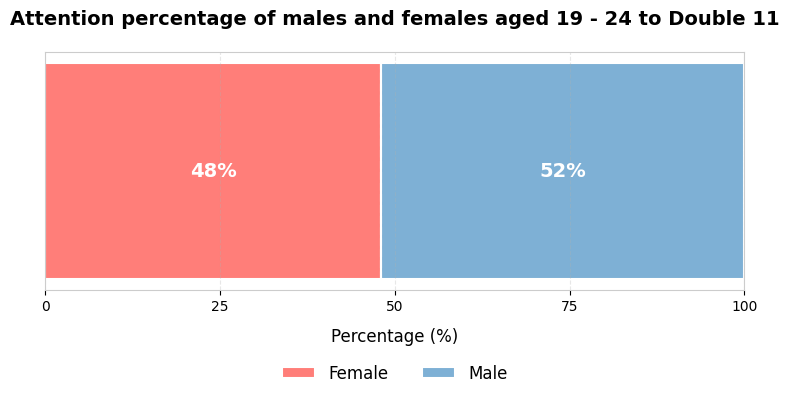

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data definition
genders = ["Female", "Male"]
gender_percents = [48, 52]
gender_colors = ['#FF7E79', '#7EB0D5']

# Create a canvas
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

# Draw a beautified horizontal segmented bar chart
bar_height = 0.4
ax.barh(0, gender_percents[0], color=gender_colors[0], 
         height=bar_height, edgecolor='white', linewidth=1.5, label=genders[0])
ax.barh(0, gender_percents[1], left=gender_percents[0], color=gender_colors[1], 
         height=bar_height, edgecolor='white', linewidth=1.5, label=genders[1])

# Add data labels
ax.text(gender_percents[0]/2, 0, f"{gender_percents[0]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')
ax.text(gender_percents[0] + gender_percents[1]/2, 0, f"{gender_percents[1]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')

# Set the bar chart style
ax.set_xlim(0, 100)
ax.set_yticks([])  # Remove the y-axis
ax.set_xlabel("Percentage (%)", fontsize=12, labelpad=10)
ax.set_title("Attention percentage of males and females aged 19 - 24 to Double 11", fontsize=14, pad=20, fontweight='bold')

# Customize the x-axis ticks
ax.set_xticks([0, 25, 50, 75, 100])
ax.tick_params(axis='x', which='major', labelsize=10)

# Add a legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), 
           ncol=2, frameon=False, fontsize=12)

# Add grid lines
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Add a border
for spine in ax.spines.values():
    spine.set_color('#cccccc')

# Add a diagonal line at the boundary - the separation line between males and females
divider_y = np.linspace(-bar_height/2, bar_height/2, 100)
divider_x = np.ones_like(divider_y) * gender_percents[0]
ax.plot(divider_x, divider_y, color='white', linewidth=1.5, linestyle='--')

# Adjust the layout
plt.tight_layout(pad=3)

# Save the chart (optional)
# plt.savefig('gender_distribution.png', dpi=300, bbox_inches='tight')

# Display the chart
plt.show()

# 文件: chart_28_5.py

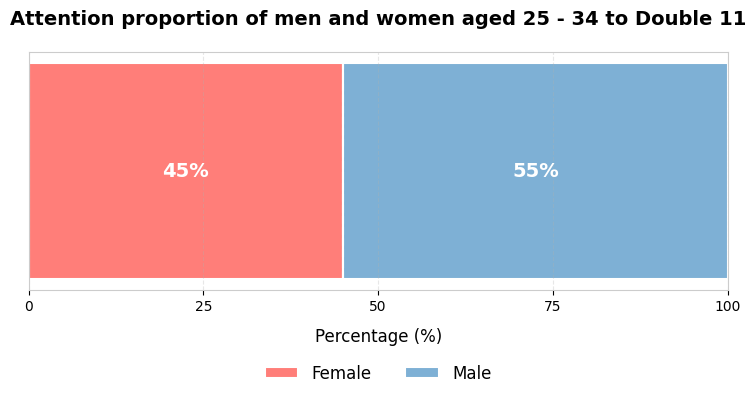

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data definition
genders = ["Female", "Male"]
gender_percents = [45, 55]
gender_colors = ['#FF7E79', '#7EB0D5']

# Create a canvas
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

# Draw a beautified horizontal segmented bar chart
bar_height = 0.4
ax.barh(0, gender_percents[0], color=gender_colors[0], 
         height=bar_height, edgecolor='white', linewidth=1.5, label=genders[0])
ax.barh(0, gender_percents[1], left=gender_percents[0], color=gender_colors[1], 
         height=bar_height, edgecolor='white', linewidth=1.5, label=genders[1])

# Add data labels
ax.text(gender_percents[0]/2, 0, f"{gender_percents[0]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')
ax.text(gender_percents[0] + gender_percents[1]/2, 0, f"{gender_percents[1]}%", 
         ha='center', va='center', fontsize=14, color='white', fontweight='bold')

# Set the bar chart style
ax.set_xlim(0, 100)
ax.set_yticks([])  # Remove the y-axis
ax.set_xlabel("Percentage (%)", fontsize=12, labelpad=10)
ax.set_title("Attention proportion of men and women aged 25 - 34 to Double 11", fontsize=14, pad=20, fontweight='bold')

# Customize the x-axis ticks
ax.set_xticks([0, 25, 50, 75, 100])
ax.tick_params(axis='x', which='major', labelsize=10)

# Add a legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), 
           ncol=2, frameon=False, fontsize=12)

# Add grid lines
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Add a border
for spine in ax.spines.values():
    spine.set_color('#cccccc')

# Add a diagonal line at the dividing point - the separation line between men and women
divider_y = np.linspace(-bar_height/2, bar_height/2, 100)
divider_x = np.ones_like(divider_y) * gender_percents[0]
ax.plot(divider_x, divider_y, color='white', linewidth=1.5, linestyle='--')

# Adjust the layout
plt.tight_layout(pad=3)

# Save the chart (optional)
# plt.savefig('gender_distribution.png', dpi=300, bbox_inches='tight')

# Display the chart
plt.show()